# Density Peak Clustering on the 2-Gaussian Mixture Data

This notebook compares the original DPC, GGDPC, DPC-KNN-PCA, SNN-DPC, DPC-CE, DPC-DLP, and DPC-MDNN on a simulated 2-Gaussian mixture data.

In [1]:
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import adjusted_rand_score
from scipy.cluster.hierarchy import dendrogram

from GGDPC import DPC, GGDPC
from DPC_variants import DPC_KNN_PCA, SNN_DPC, DPC_CE, DPC_DLP, DPC_MDNN
from utils import plot_clusters, sample_gaussian_mixture

results = {}

def plot_clustering(X, labels, centers, title):
    plt.figure(figsize=(7, 6))
    plt.scatter(X[:, 0], X[:, 1], c=labels, cmap="viridis", s=15)
    if len(centers):
        plt.scatter(X[centers, 0], X[centers, 1], c="red", marker="X", s=90,
                    label="Cluster Centers")
        plt.legend()
    plt.title(title)
    plt.xlabel("X1")
    plt.ylabel("X2")
    plt.axis("equal")
    plt.show()

def record_result(name, true_labels, pred_labels, elapsed):
    ari = adjusted_rand_score(true_labels, pred_labels)
    results[name] = {
        "Method": name,
        "ARI": ari,
        "Clusters Found": np.unique(pred_labels[pred_labels != -1]).size,
        "Noise Points": np.sum(pred_labels == -1),
        "Runtime (s)": elapsed}
    print(f"Adjusted Rand Index: {ari:.4f}")
    print(f"Runtime: {elapsed:.3f} seconds")

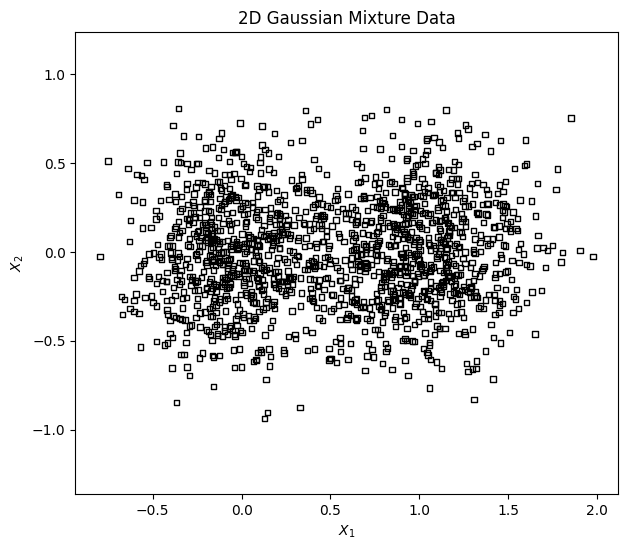

0    726
1    774
Name: count, dtype: int64

In [2]:
X_dat, true_labels = sample_gaussian_mixture(n_samples=1500, mu_lst=np.array([[0, 0], [1, 0]]), 
                                             sigma_lst=np.array([0.3**2, 0.3**2]), 
                                             random_state=0, return_labels=True)

n_clusters = 2

plt.figure(figsize=(7, 6))
plt.scatter(X_dat[:, 0], X_dat[:, 1], marker="s", facecolors="none",
            edgecolors="black", s=15)
plt.title("2D Gaussian Mixture Data")
plt.xlabel(r"$X_1$")
plt.ylabel(r"$X_2$")
plt.axis("equal")
plt.show()

pd.Series(true_labels).value_counts().sort_index()

### Traditional DPC

The existing implementation automatically identifies centers using its default three-standard-deviation rule.

In [3]:
from matplotlib.collections import LineCollection

def plot_clusters(X, clu, start, end, centers, directed=False, title=None, figsize=(7, 6),
                  boundary=None, save_path=None):
    plt.figure(figsize=figsize)
    segments = np.stack([X[start], X[end]], axis=1)

    # plot all nodes
    pts = np.vstack([X[start], X[end]])
    plt.scatter(X[:, 0], X[:, 1], c=clu, cmap='viridis', s=25)
    plt.scatter(X[centers, 0], X[centers, 1], c='red', marker='X', s=70, label='Cluster centers')
    if directed:
        plt.quiver(X[start, 0], X[start, 1], X[end, 0] - X[start, 0], X[end, 1] - X[start, 1], 
                   angles='xy', scale_units='xy', scale=1, color='black', width=0.003, alpha=0.65)
    else:
        lc = LineCollection(segments, colors="black", linewidths=1, alpha=0.65, width=0.003)
        plt.gca().add_collection(lc)
    if boundary is not None:
        # Draw the decision boundary
        # plt.axvline(x=boundary, color='blue', linestyle='dashed', label='Oracle decision boundary')

        # Get limits after plotting the data
        xmin, xmax = plt.xlim()

        # Color the decision regions
        plt.axvspan(xmin, boundary, color="#d7f2a1", alpha=0.6, zorder=0)
        plt.axvspan(boundary, xmax, color='#d6d5ff', alpha=0.6, zorder=0)

        # Prevent axvspan from changing the limits
        plt.xlim(xmin, xmax)

    plt.legend(fontsize=10)
    plt.title(title)
    plt.xlabel(r"$X_1$")
    plt.ylabel(r"$X_2$")
    plt.tight_layout()
    if save_path is not None:
        plt.savefig(save_path)
    plt.show()

/tmp/ipykernel_187875/1280904732.py:38: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  plt.savefig(save_path)


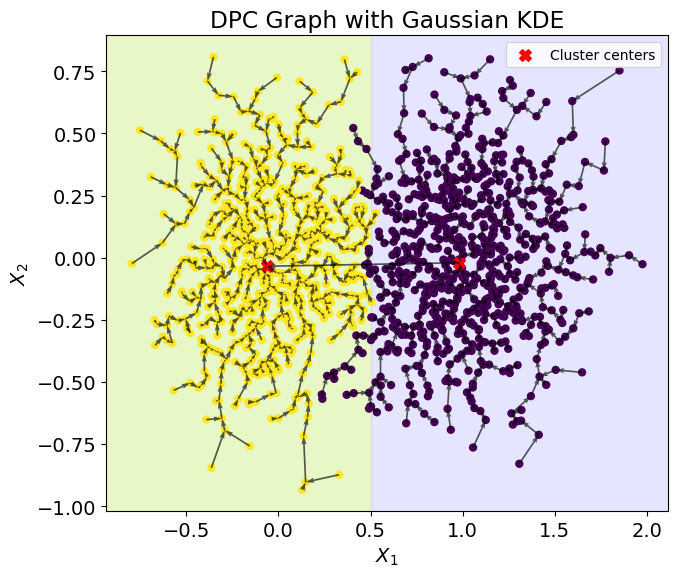

Adjusted Rand Index: 0.8075
Runtime: 0.866 seconds


In [4]:
start = time.perf_counter()
h = None
DPC_labels, DPC_det = DPC(X_dat, den_est=None, dist_mat=None, bandwidth=h, den_thres=0, center_quantile=None,
                          scaling=False, center_z=4, return_details=True)
elapsed = time.perf_counter() - start

plt.matplotlib.rcParams.update({
    "font.size": 14,
    "pdf.fonttype": 42,
    "ps.fonttype": 42,
})
plot_clusters(X_dat, DPC_labels, np.arange(X_dat.shape[0])[DPC_det['1nn_higher'] != -1], 
              DPC_det['1nn_higher'][DPC_det['1nn_higher'] != -1], DPC_det['cluster_centers'], directed=True, figsize=(7, 6),
              title="DPC Graph with Gaussian KDE", boundary=0.5,
              save_path="./Figures/GMM_DPC.pdf")
record_result("DPC", true_labels, DPC_labels, elapsed)

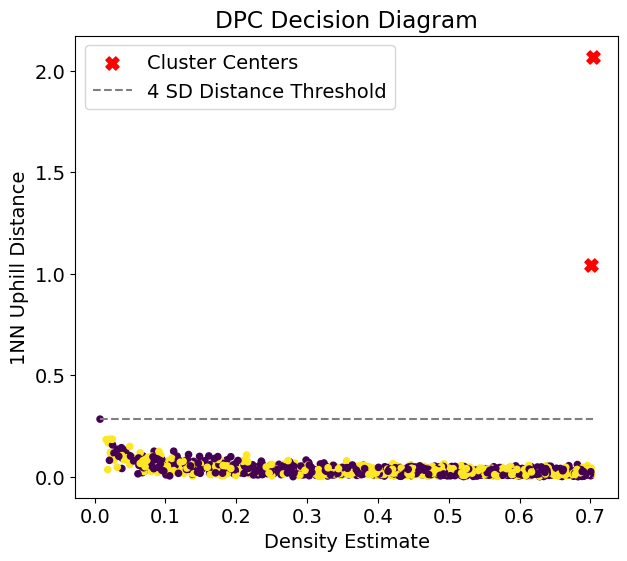

In [5]:
plt.figure(figsize=(7, 6))
plt.scatter(DPC_det["den_est"], DPC_det["delta"], c=DPC_labels,
            cmap="viridis", s=20)
plt.scatter(DPC_det["den_est"][DPC_det["cluster_centers"]], DPC_det["delta"][DPC_det["cluster_centers"]],
            c="red", marker="X", s=90, label="Cluster Centers")
plt.hlines(y=4*np.std(DPC_det['delta']) + np.mean(DPC_det['delta']), xmin=min(DPC_det['den_est']), 
            xmax=max(DPC_det['den_est']), colors='grey', linestyles='dashed', label='4 SD Distance Threshold')
plt.title("DPC Decision Diagram")
plt.xlabel("Density Estimate")
plt.ylabel("1NN Uphill Distance")
plt.legend()
plt.show()

### GGDPC

GGDPC uses the one-step Gaussian mean-shift location to guide the nearest-higher-density link.

/tmp/ipykernel_187875/1280904732.py:38: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  plt.savefig(save_path)


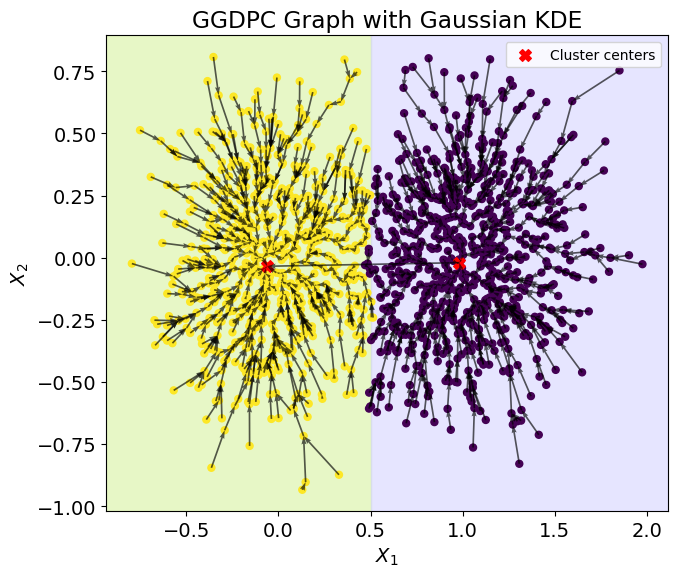

Adjusted Rand Index: 0.8438
Runtime: 2.310 seconds


In [6]:
start = time.perf_counter()
h = None
GGDPC_labels, GGDPC_det = GGDPC(X_dat, den_est=None, grad_new=None, den_thres=0, h_den=h, h_grad=h,
                                center_quantile=None, scaling=False, center_z=4, return_details=True, graph_dist=True, 
                                dendro=True)
elapsed = time.perf_counter() - start

# plot_clustering(X_dat, GGDPC_labels, GGDPC_det["cluster_centers"],
#                 "GGDPC Clustering With Gaussian KDE")
plot_clusters(X_dat, GGDPC_labels, np.arange(X_dat.shape[0])[GGDPC_det['gg1nn_higher'] != -1], 
              GGDPC_det['gg1nn_higher'][GGDPC_det['gg1nn_higher'] != -1], GGDPC_det['cluster_centers'], figsize=(7, 6),
              directed=True, title='GGDPC Graph with Gaussian KDE', boundary=0.5, 
              save_path="./Figures/GMM_GGDPC.pdf")
record_result("GGDPC", true_labels, GGDPC_labels, elapsed)

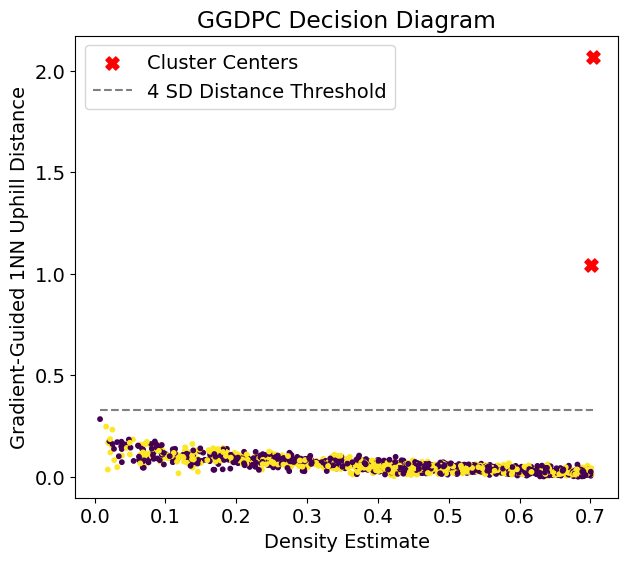

In [7]:
plt.figure(figsize=(7, 6))
plt.scatter(GGDPC_det["den_est"], GGDPC_det["delta"], c=GGDPC_labels,
            cmap="viridis", s=10)
plt.scatter(GGDPC_det["den_est"][GGDPC_det["cluster_centers"]], GGDPC_det["delta"][GGDPC_det["cluster_centers"]],
            c="red", marker="X", s=90, label="Cluster Centers")
plt.hlines(y=4*np.std(GGDPC_det['delta']) + np.mean(GGDPC_det['delta']), xmin=min(GGDPC_det['den_est']), 
            xmax=max(GGDPC_det['den_est']), colors='grey', linestyles='dashed', label='4 SD Distance Threshold')
plt.title("GGDPC Decision Diagram")
plt.xlabel("Density Estimate")
plt.ylabel("Gradient-Guided 1NN Uphill Distance")
plt.legend()
plt.show()

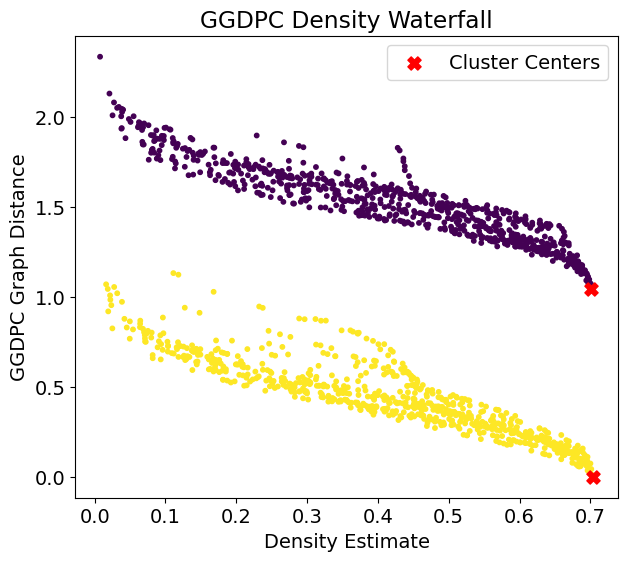

In [8]:
plt.figure(figsize=(7, 6))
plt.scatter(GGDPC_det["den_est"], GGDPC_det["graph_dist"], c=GGDPC_labels, cmap="viridis", s=10)
plt.scatter(GGDPC_det["den_est"][GGDPC_det["cluster_centers"]], GGDPC_det["graph_dist"][GGDPC_det["cluster_centers"]],
            c="red", marker="X", s=90, label="Cluster Centers")
plt.title("GGDPC Density Waterfall")
plt.xlabel("Density Estimate")
plt.ylabel("GGDPC Graph Distance")
plt.legend()
plt.show()

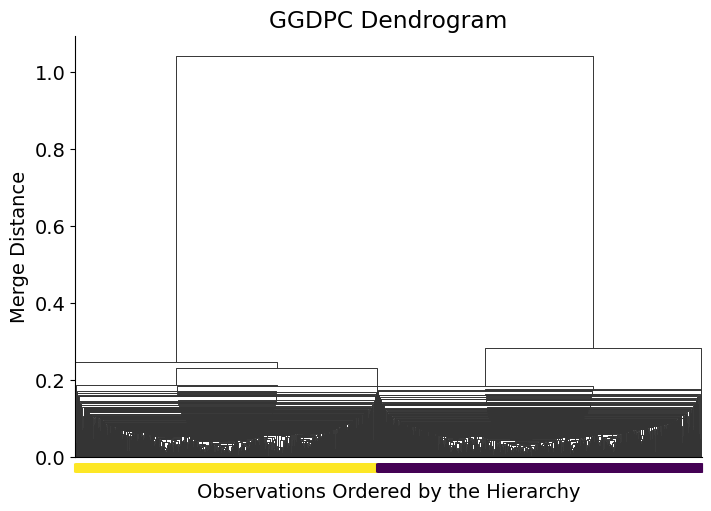

In [9]:
Z = GGDPC_det["dendrogram"]
labels = np.asarray(GGDPC_labels)

fig, ax = plt.subplots(figsize=(7, 5), constrained_layout=True)

tree = dendrogram(Z, ax=ax, no_labels=True, color_threshold=0, above_threshold_color="#343434")

for branches in ax.collections:
    branches.set_linewidth(0.7)

# Add cluster colors in dendrogram leaf order
ordered_labels = labels[tree["leaves"]]
leaf_positions = np.arange(5, 10 * len(labels) + 5, 10)

ax.scatter(
    leaf_positions,
    np.full(len(labels), -0.025),
    # c=[color_map[label] for label in ordered_labels],
    c=ordered_labels,
    cmap="viridis",
    vmin=labels.min(),
    vmax=labels.max(),
    marker="|",
    s=50,
    linewidths=2.2,
    transform=ax.get_xaxis_transform(),
    clip_on=False,
)

ax.set_title("GGDPC Dendrogram")
ax.set_xlabel("Observations Ordered by the Hierarchy", labelpad=18)
ax.set_ylabel("Merge Distance")
ax.spines[["top", "right"]].set_visible(False)

plt.show()

### DPC-KNN-PCA

Find the "optimal" k based on ARI. Both principal components are retained because this dataset is two-dimensional.

Optimal k: 9
Best ARI: 0.8268


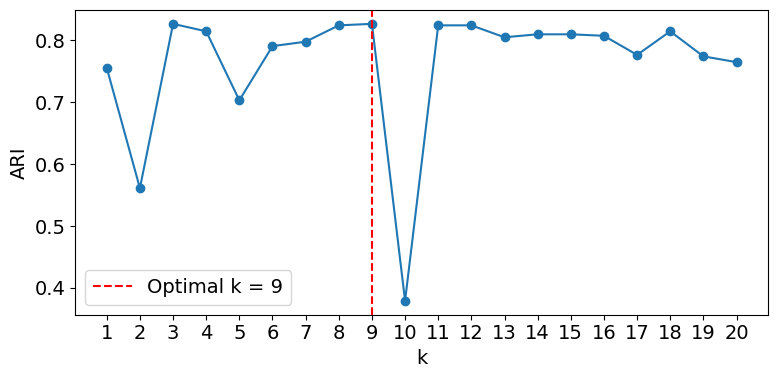

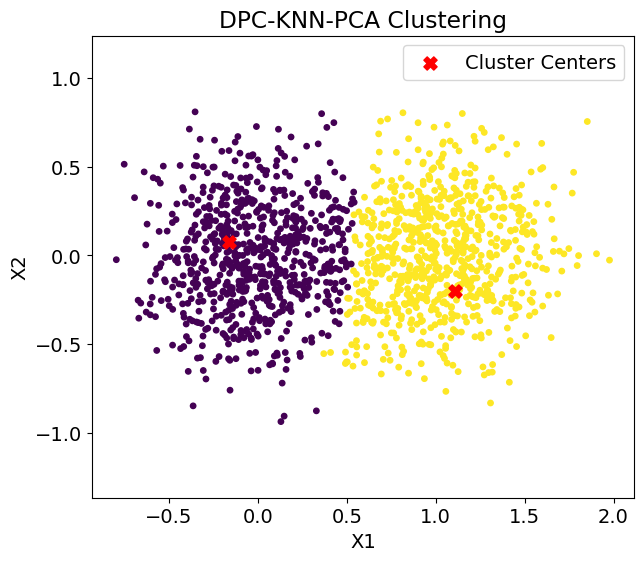

Adjusted Rand Index: 0.8268
Runtime: 0.340 seconds


In [14]:
# Search k = 1, ..., 20 (while respecting k < number of samples)
k_values = range(2, min(20, len(X_dat) - 1) + 1)
k_scores = {}

for k in k_values:
    labels_k, details_k = DPC_KNN_PCA(
        X_dat,
        n_clusters=n_clusters,
        k=k,
        n_components=2,
        return_details=True
    )

    # Evaluate against the ground-truth cluster labels
    k_scores[k] = adjusted_rand_score(true_labels, labels_k)

optimal_k = max(k_scores, key=k_scores.get)

print(f"Optimal k: {optimal_k}")
print(f"Best ARI: {k_scores[optimal_k]:.4f}")

# Optional: visualize scores
plt.figure(figsize=(8, 4))
plt.plot(list(k_scores.keys()), list(k_scores.values()), marker="o")
plt.axvline(optimal_k, color="red", linestyle="--",
            label=f"Optimal k = {optimal_k}")
plt.xlabel("k")
plt.ylabel("ARI")
plt.xticks(list(k_values))
plt.legend()
plt.tight_layout()
plt.show()

# Run the final model
start = time.perf_counter()
DPC_KNN_PCA_labels, DPC_KNN_PCA_det = DPC_KNN_PCA(
    X_dat, n_clusters=n_clusters, k=optimal_k, n_components=2, return_details=True)
elapsed = time.perf_counter() - start

plot_clustering(X_dat, DPC_KNN_PCA_labels, DPC_KNN_PCA_det["cluster_centers"],
                "DPC-KNN-PCA Clustering")
record_result("DPC-KNN-PCA", true_labels, DPC_KNN_PCA_labels, elapsed)

### SNN-DPC

Find the "optimal" k based on ARI. Min-max scaling follows the released SNN-DPC runner.

Optimal k: 8
Best ARI: 0.7790


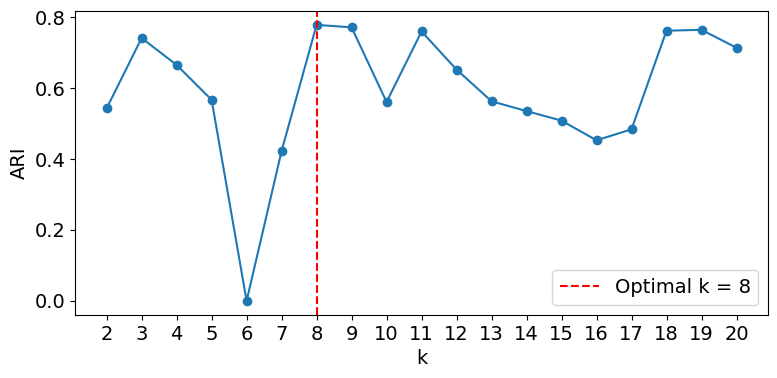

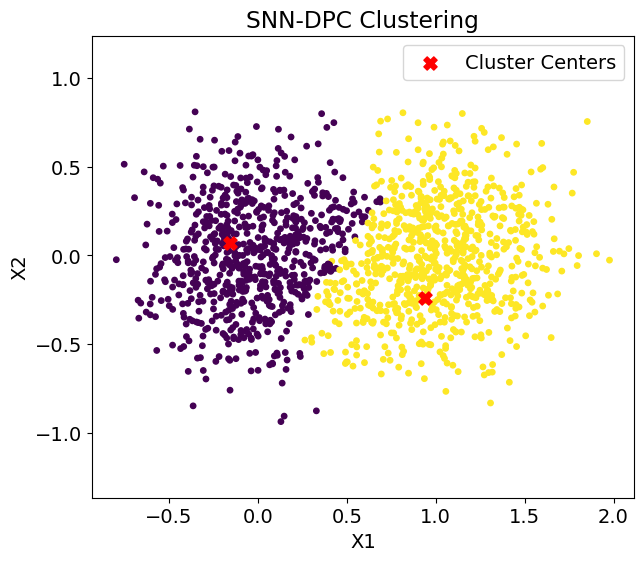

Adjusted Rand Index: 0.7790
Runtime: 7.854 seconds


In [16]:
# Search k = 1, ..., 20 (while respecting k < number of samples)
k_values = range(2, min(20, len(X_dat)) + 1)
k_scores = {}

for k in k_values:
    labels_k, details_k = SNN_DPC(X_dat, n_clusters=n_clusters, k=k, scale=True, return_details=True)

    # Evaluate against the ground-truth cluster labels
    k_scores[k] = adjusted_rand_score(true_labels, labels_k)

optimal_k = max(k_scores, key=k_scores.get)

print(f"Optimal k: {optimal_k}")
print(f"Best ARI: {k_scores[optimal_k]:.4f}")

# Optional: visualize scores
plt.figure(figsize=(8, 4))
plt.plot(list(k_scores.keys()), list(k_scores.values()), marker="o")
plt.axvline(optimal_k, color="red", linestyle="--", label=f"Optimal k = {optimal_k}")
plt.xlabel("k")
plt.ylabel("ARI")
plt.xticks(list(k_values))
plt.legend()
plt.tight_layout()
plt.show()

start = time.perf_counter()
SNN_DPC_labels, SNN_DPC_det = SNN_DPC(
    X_dat, n_clusters=n_clusters, k=optimal_k, scale=True, return_details=True)
elapsed = time.perf_counter() - start

plot_clustering(X_dat, SNN_DPC_labels, SNN_DPC_det["cluster_centers"],
                "SNN-DPC Clustering")
record_result("SNN-DPC", true_labels, SNN_DPC_labels, elapsed)

### DPC-CE

We set $d_c=2\%$, $T_r=0.25$, and $P_r=0.3$. The known cluster count replaces the MATLAB code's interactive rectangle selection.

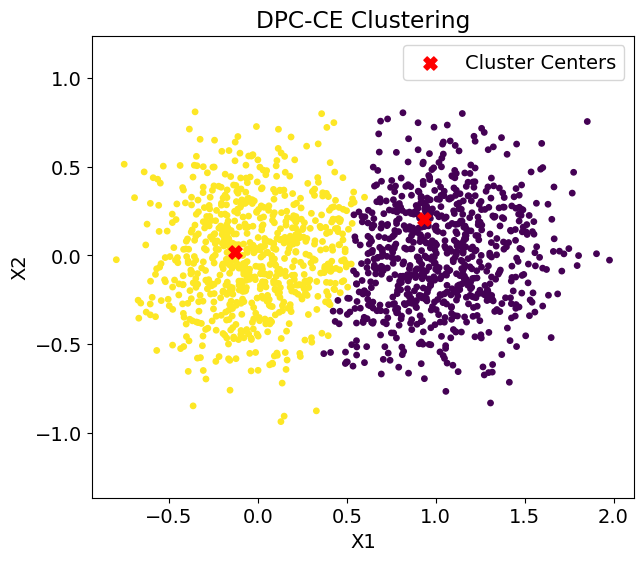

Adjusted Rand Index: 0.8171
Runtime: 7.371 seconds


In [17]:
start = time.perf_counter()
DPC_CE_labels, DPC_CE_det = DPC_CE(
    X_dat, n_clusters=n_clusters, dc_percent=2.0, path_distance_ratio=0.25,
    distance_penalty_ratio=0.3, return_details=True)
elapsed = time.perf_counter() - start

plot_clustering(X_dat, DPC_CE_labels, DPC_CE_det["cluster_centers"],
                "DPC-CE Clustering")
record_result("DPC-CE", true_labels, DPC_CE_labels, elapsed)

### DPC-DLP

We use the neighbor fraction as $p=1\%=0.01$. The remaining propagation settings follow the authors' released MATLAB implementation.

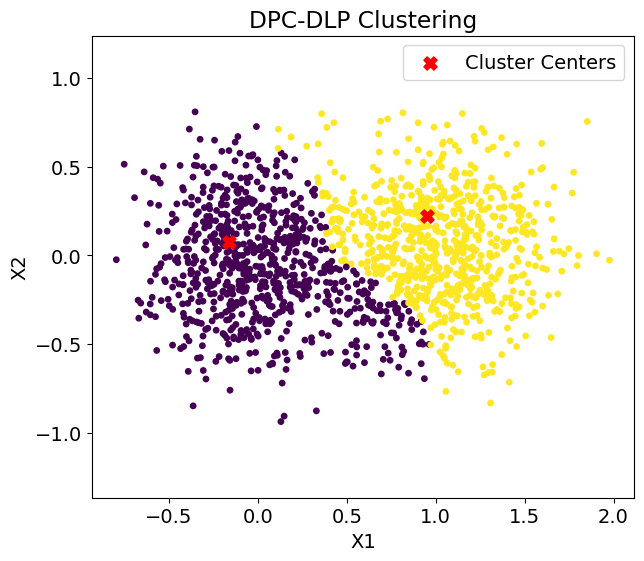

Adjusted Rand Index: 0.6570
Runtime: 2.542 seconds


In [21]:
start = time.perf_counter()
DPC_DLP_labels, DPC_DLP_det = DPC_DLP(
    X_dat, n_clusters=n_clusters, neighbor_fraction=0.01,
    return_details=True)
elapsed = time.perf_counter() - start

plot_clustering(X_dat, DPC_DLP_labels, DPC_DLP_det["cluster_centers"],
                "DPC-DLP Clustering")
record_result("DPC-DLP", true_labels, DPC_DLP_labels, elapsed)

### DPC-MDNN

Find the optimal number of manifold neighbors via ARI. Then, DPC-MDNN automatically finds its natural-neighbor scale.

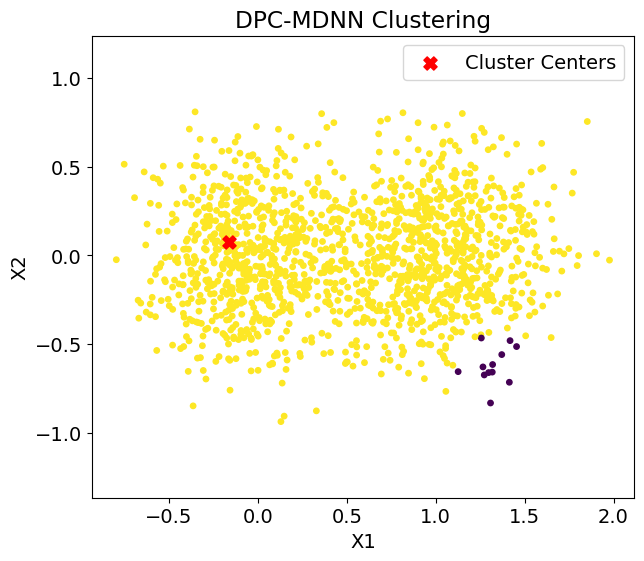

Adjusted Rand Index: -0.0008
Runtime: 2.822 seconds


In [31]:
# Valid range: 2 <= manifold_neighbors < number of samples
neighbor_values = range(2, min(20, len(X_dat) - 1) + 1)
neighbor_scores = {}

for manifold_neighbors in neighbor_values:
    labels_candidate = DPC_MDNN(
        X_dat,
        n_clusters=n_clusters,
        manifold_neighbors=manifold_neighbors,
        scale=True,
        return_details=False
    )

    neighbor_scores[manifold_neighbors] = adjusted_rand_score(true_labels, labels_candidate)

# Select the smallest value if multiple values have the same maximum ARI
optimal_neighbors = max(neighbor_scores, key=neighbor_scores.get)

print(f"Optimal manifold_neighbors: {optimal_neighbors}")
print(f"Best ARI: {neighbor_scores[optimal_neighbors]:.4f}")

# Visualize the search results
plt.figure(figsize=(8, 4))
plt.plot(
    list(neighbor_scores.keys()),
    list(neighbor_scores.values()),
    marker="o"
)
plt.axvline(optimal_neighbors,
    color="red",
    linestyle="--",
    label=f"Optimal neighbors = {optimal_neighbors}"
)
plt.xlabel("Manifold neighbors")
plt.ylabel("Adjusted Rand Index (ARI)")
plt.xticks(list(neighbor_values))
plt.legend()
plt.tight_layout()
plt.show()

# Run the final model with the selected value
start = time.perf_counter()
DPC_MDNN_labels, DPC_MDNN_det = DPC_MDNN(
    X_dat, n_clusters=n_clusters, manifold_neighbors=optimal_neighbors, scale=True, return_details=True)
elapsed = time.perf_counter() - start

plot_clustering(X_dat, DPC_MDNN_labels, DPC_MDNN_det["cluster_centers"],
                "DPC-MDNN Clustering")
record_result("DPC-MDNN", true_labels, DPC_MDNN_labels, elapsed)

### Comparison Summary

ARI is invariant to permutations of cluster-label values, so no label alignment is required.

In [30]:
summary = pd.DataFrame(results.values()).sort_values("ARI", ascending=False)
summary.round({"ARI": 4, "Runtime (s)": 3})

,Method,ARI,Clusters Found,Noise Points,Runtime (s)
1,GGDPC,0.8438,2,0,2.310
2,DPC-KNN-PCA,0.8268,2,0,0.340
4,DPC-CE,0.8171,2,0,7.371
0,DPC,0.8075,2,0,0.866
3,SNN-DPC,0.7790,2,0,7.854
5,DPC-DLP,0.6570,2,0,2.542
6,DPC-MDNN,0.0059,2,0,2.183
